# Composable Operations

## What you'll learn

- Combine tightly coupled operations into a single pipeline step with `pipeline.chain()`
- Pass artifacts in-memory between operations (no Delta Lake round-trips)
- Choose how intermediate artifacts are handled (discard, persist)

**Prerequisites:** [Sources and Chains](01-sources-and-chains.ipynb), [Advanced Patterns](05-advanced-patterns.ipynb)
**Estimated time:** 15 minutes

---

Each `pipeline.run()` call is a separate step: inputs are read from Delta
Lake, outputs are written back. When operations are tightly coupled — for
example, transform → score where you always score immediately after
transforming — those intermediate round-trips are pure overhead.

`pipeline.chain()` lets you compose multiple creator operations into a
**single step**. Artifacts flow in-memory between operations within one
worker, and only the final outputs are committed to Delta Lake.

| Approach | Steps | I/O per operation | Use when |
|----------|-------|-------------------|----------|
| Separate `run()` calls | N | Read + write each | Operations are reused independently |
| `chain()` | 1 | In-memory between ops | Operations are always run together |

In [1]:
from __future__ import annotations

from artisan.operations.examples import (
    DataGenerator,
    DataTransformer,
    MetricCalculator,
)
from artisan.orchestration import PipelineManager
from artisan.utils import tutorial_setup
from artisan.utils.logging import configure_logging
from artisan.visualization import (
    build_macro_graph,
    build_micro_graph,
    inspect_pipeline,
)

configure_logging()

> **Graph legend:** See [Sources and Chains](01-sources-and-chains.ipynb) for box/arrow key.

## Baseline: separate `run()` calls

First, let's build a three-step pipeline the traditional way — generate
data, transform it, then score it. Each step reads from and writes to
Delta Lake.

```
generate ──→ transform ──→ score
   (3 datasets)  (3 datasets)  (3 metrics)
```

This produces 3 steps and 3 Delta Lake round-trips.

In [2]:
env_baseline = tutorial_setup("baseline")

In [3]:
pipeline = PipelineManager.create(
    name="baseline",
    delta_root=env_baseline.delta_root,
    staging_root=env_baseline.staging_root,
    working_root=env_baseline.working_root,
)
output = pipeline.output

# Step 0: Generate 3 datasets
pipeline.run(operation=DataGenerator, name="generate", params={"count": 3, "seed": 42})

# Step 1: Transform each dataset
pipeline.run(
    operation=DataTransformer,
    name="transform",
    inputs={"dataset": output("generate", "datasets")},
    params={"scale_factor": 2.0, "variants": 1, "seed": 100},
)

# Step 2: Score each transformed dataset
pipeline.run(
    operation=MetricCalculator,
    name="score",
    inputs={"dataset": output("transform", "dataset")},
)

result_baseline = pipeline.finalize()

15:46:42.628 | INFO    | artisan.orchestration.prefect_server - Prefect server: http://ach94-dongle.dhcp.ipd:4701/api (source: discovery_file)

15:46:42.630 | INFO    | artisan.orchestration.pipeline_manager - Pipeline 'baseline' initialized (run_id=baseline_20260306_234642_9cd37118)

15:46:42.631 | INFO    | artisan.orchestration.pipeline_manager -   delta_root: /Users/andrewhunt/git/artisan-dev/src/artisan/utils/runs/baseline/delta

15:46:42.631 | INFO    | artisan.orchestration.pipeline_manager -   staging_root: /Users/andrewhunt/git/artisan-dev/src/artisan/utils/runs/baseline/staging

15:46:42.638 | INFO    | artisan.orchestration.pipeline_manager - Step 0 (generate) starting... [backend=local]

...

15:46:46.423 | INFO    | artisan.orchestration.pipeline_manager - Pipeline 'baseline' complete: 3 steps, all succeeded

15:46:46.423 | INFO    | artisan.orchestration.pipeline_manager -   Step 0: generate         1.2s  [1/1]

15:46:46.424 | INFO    | artisan.orchestration.pipeline_manager -   Step 1: transform        1.3s  [3/3]

15:46:46.424 | INFO    | artisan.orchestration.pipeline_manager -   Step 2: score            1.2s  [3/3]

15:46:46.425 | INFO    | artisan.orchestration.pipeline_manager -   Total: 3.8s

In [4]:
inspect_pipeline(env_baseline.delta_root)

step,operation,status,produced,duration
i64,str,str,str,str
0,"""generate""","""ok""","""3 data""","""1.2s"""
1,"""transform""","""ok""","""3 data""","""1.3s"""
2,"""score""","""ok""","""3 metric""","""1.2s"""


Three steps, three Delta Lake commits. The transform step wrote 3
intermediate datasets that were immediately read back by the score step.
If these operations are always run together, that intermediate I/O is
wasted work.

## Chaining operations into a single step

`pipeline.chain()` returns a `ChainBuilder`. Add operations with `.add()`,
then call `.run()` to execute the chain as a single pipeline step. The
intermediate artifacts (transform outputs) are passed in-memory to the
next operation — no Delta Lake round-trip.

```
generate ──→ [ transform → score ]  ← single step
   (3 datasets)      (3 metrics)
```

This produces 2 steps instead of 3.

In [5]:
env_chain = tutorial_setup("chain_basic")

In [6]:
pipeline = PipelineManager.create(
    name="chain_basic",
    delta_root=env_chain.delta_root,
    staging_root=env_chain.staging_root,
    working_root=env_chain.working_root,
)
output = pipeline.output

# Step 0: Generate 3 datasets (same as baseline)
pipeline.run(operation=DataGenerator, name="generate", params={"count": 3, "seed": 42})

# Step 1: Chain transform + score into a single step
chain = pipeline.chain(
    inputs={"dataset": output("generate", "datasets")},
    name="transform_and_score",
)
chain.add(
    DataTransformer,
    params={"scale_factor": 2.0, "variants": 1, "seed": 100},
)
chain.add(MetricCalculator)
chain_result = chain.run()

result_chain = pipeline.finalize()

15:46:51.669 | INFO    | artisan.orchestration.prefect_server - Prefect server: http://ach94-dongle.dhcp.ipd:4701/api (source: env:PREFECT_API_URL)

15:46:51.670 | INFO    | artisan.orchestration.pipeline_manager - Pipeline 'chain_basic' initialized (run_id=chain_basic_20260306_234651_de336ea4)

15:46:51.671 | INFO    | artisan.orchestration.pipeline_manager -   delta_root: /Users/andrewhunt/git/artisan-dev/src/artisan/utils/runs/chain_basic/delta

15:46:51.671 | INFO    | artisan.orchestration.pipeline_manager -   staging_root: /Users/andrewhunt/git/artisan-dev/src/artisan/utils/runs/chain_basic/staging

15:46:51.676 | INFO    | artisan.orchestration.pipeline_manager - Step 0 (generate) starting... [backend=local]

...

15:46:53.928 | INFO    | artisan.orchestration.pipeline_manager - Step 1 (transform_and_score) completed in 1.1s [3/3 succeeded]

15:46:53.929 | INFO    | artisan.orchestration.pipeline_manager - Pipeline 'chain_basic' complete: 2 steps, all succeeded

15:46:53.929 | INFO    | artisan.orchestration.pipeline_manager -   Step 0: generate         1.1s  [1/1]

15:46:53.930 | INFO    | artisan.orchestration.pipeline_manager -   Step 1: transform_and_score 1.1s  [3/3]

15:46:53.931 | INFO    | artisan.orchestration.pipeline_manager -   Total: 2.3s

In [7]:
inspect_pipeline(env_chain.delta_root)

step,operation,status,produced,duration
i64,str,str,str,str
0,"""generate""","""ok""","""3 data""","""1.1s"""
1,"""transform_and_score""","""ok""","""3 metric""","""1.1s"""


Two steps instead of three. The chain produced the same 3 metrics as the
baseline, but the intermediate transformed datasets were never written to
Delta Lake — they were passed directly in-memory from `DataTransformer`
to `MetricCalculator` within each worker.

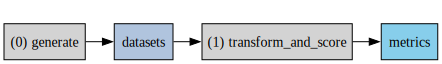

In [8]:
build_macro_graph(env_chain.delta_root)

The macro graph shows the chain as a single node. From the pipeline's
perspective, `transform_and_score` is one step that accepts datasets
and produces metrics.

## Fluent builder syntax

Since `chain()` and `add()` both return the builder, you can compose
them into a single expression. If you don't provide a `name`, it's
auto-generated from the operation names.

In [9]:
env_fluent = tutorial_setup("fluent")

In [10]:
pipeline = PipelineManager.create(
    name="fluent",
    delta_root=env_fluent.delta_root,
    staging_root=env_fluent.staging_root,
    working_root=env_fluent.working_root,
)
output = pipeline.output

pipeline.run(operation=DataGenerator, name="generate", params={"count": 2, "seed": 42})

# Fluent one-liner: chain → add → add → run
result = (
    pipeline.chain(inputs={"dataset": output("generate", "datasets")})
    .add(DataTransformer, params={"scale_factor": 0.5, "variants": 1, "seed": 50})
    .add(MetricCalculator)
    .run()
)

print(f"Step name: {result.step_name}")
print(f"Success: {result.success}")
print(f"Output roles: {result.output_roles}")

pipeline.finalize()

15:47:40.554 | INFO    | artisan.orchestration.prefect_server - Prefect server: http://ach94-dongle.dhcp.ipd:4701/api (source: env:PREFECT_API_URL)

15:47:40.555 | INFO    | artisan.orchestration.pipeline_manager - Pipeline 'fluent' initialized (run_id=fluent_20260306_234740_4b7a91b5)

15:47:40.556 | INFO    | artisan.orchestration.pipeline_manager -   delta_root: /Users/andrewhunt/git/artisan-dev/src/artisan/utils/runs/fluent/delta

15:47:40.556 | INFO    | artisan.orchestration.pipeline_manager -   staging_root: /Users/andrewhunt/git/artisan-dev/src/artisan/utils/runs/fluent/staging

15:47:40.562 | INFO    | artisan.orchestration.pipeline_manager - Step 0 (generate) starting... [backend=local]

...

15:47:42.855 | INFO    | artisan.orchestration.pipeline_manager - Pipeline 'fluent' complete: 2 steps, all succeeded

15:47:42.856 | INFO    | artisan.orchestration.pipeline_manager -   Step 0: generate         1.1s  [1/1]

15:47:42.857 | INFO    | artisan.orchestration.pipeline_manager -   Step 1: data_transformer_chain_metric_calculator 1.2s  [2/2]

15:47:42.857 | INFO    | artisan.orchestration.pipeline_manager -   Total: 2.3s

{'pipeline_name': 'fluent',
 'total_steps': 2,
 'steps': [{'step_number': 0,
   'name': 'generate',
   'success': True,
   'total': 1,
   'succeeded': 1,
   'failed': 0,
   'duration_seconds': 1.1149017079733312},
  {'step_number': 1,
   'name': 'data_transformer_chain_metric_calculator',
   'success': True,
   'total': 2,
   'succeeded': 2,
   'failed': 0,
   'duration_seconds': 1.1645902920281515}],
 'overall_success': True}

Without an explicit `name`, the step is named by joining the operation
names: `data_transformer_chain_metric_calculator`. Use a custom `name`
when you want something more readable.

## Wiring chain output to downstream steps

Chain outputs are referenced the same way as regular step outputs. Use
`pipeline.output(chain_name, role)` to feed chain results into subsequent
steps.

```
generate ──→ [ transform → transform ]  ──→ score
                 (double_transform)
```

In [11]:
env_downstream = tutorial_setup("chain_downstream")

In [12]:
pipeline = PipelineManager.create(
    name="chain_downstream",
    delta_root=env_downstream.delta_root,
    staging_root=env_downstream.staging_root,
    working_root=env_downstream.working_root,
)
output = pipeline.output

pipeline.run(operation=DataGenerator, name="generate", params={"count": 2, "seed": 42})

# Chain two transforms together
chain = pipeline.chain(
    inputs={"dataset": output("generate", "datasets")},
    name="double_transform",
)
chain.add(DataTransformer, params={"scale_factor": 2.0, "variants": 1, "seed": 10})
chain.add(DataTransformer, params={"scale_factor": 0.5, "variants": 1, "seed": 20})
chain.run()

# Wire chain output to a downstream step
pipeline.run(
    operation=MetricCalculator,
    name="score",
    inputs={"dataset": output("double_transform", "dataset")},
)

result_downstream = pipeline.finalize()

15:48:26.753 | INFO    | artisan.orchestration.prefect_server - Prefect server: http://ach94-dongle.dhcp.ipd:4701/api (source: env:PREFECT_API_URL)

15:48:26.755 | INFO    | artisan.orchestration.pipeline_manager - Pipeline 'chain_downstream' initialized (run_id=chain_downstream_20260306_234826_266dd7b7)

15:48:26.755 | INFO    | artisan.orchestration.pipeline_manager -   delta_root: /Users/andrewhunt/git/artisan-dev/src/artisan/utils/runs/chain_downstream/delta

15:48:26.756 | INFO    | artisan.orchestration.pipeline_manager -   staging_root: /Users/andrewhunt/git/artisan-dev/src/artisan/utils/runs/chain_downstream/staging

15:48:26.761 | INFO    | artisan.orchestration.pipeline_manager - Step 0 (generate) starting... [backend=local]

...

15:48:30.086 | INFO    | artisan.orchestration.pipeline_manager - Pipeline 'chain_downstream' complete: 3 steps, all succeeded

15:48:30.087 | INFO    | artisan.orchestration.pipeline_manager -   Step 0: generate         1.1s  [1/1]

15:48:30.088 | INFO    | artisan.orchestration.pipeline_manager -   Step 1: double_transform 1.1s  [2/2]

15:48:30.088 | INFO    | artisan.orchestration.pipeline_manager -   Step 2: score            1.1s  [2/2]

15:48:30.089 | INFO    | artisan.orchestration.pipeline_manager -   Total: 3.3s

In [13]:
inspect_pipeline(env_downstream.delta_root)

step,operation,status,produced,duration
i64,str,str,str,str
0,"""generate""","""ok""","""2 data""","""1.1s"""
1,"""double_transform""","""ok""","""2 data""","""1.1s"""
2,"""score""","""ok""","""2 metric""","""1.1s"""


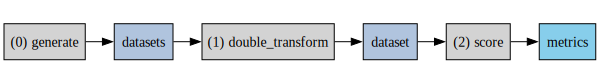

In [14]:
build_macro_graph(env_downstream.delta_root)

The chain appears as a single node in the DAG. The downstream `score`
step receives the final outputs of the chain (the second transform's
datasets) — it has no visibility into the internal chain operations.

## Persisting intermediate artifacts

By default, chains discard intermediate artifacts — only the final
operation's outputs are committed to Delta Lake. If you need the
intermediates for debugging or analysis, set `intermediates="persist"`.

| Mode | Intermediates in Delta | Provenance edges |
|------|----------------------|-----------------|
| `"discard"` (default) | No | Step-boundary only (input → final output) |
| `"persist"` | Yes | Both internal and step-boundary edges |

In [15]:
env_persist = tutorial_setup("chain_persist")

In [16]:
pipeline = PipelineManager.create(
    name="chain_persist",
    delta_root=env_persist.delta_root,
    staging_root=env_persist.staging_root,
    working_root=env_persist.working_root,
)
output = pipeline.output

pipeline.run(operation=DataGenerator, name="generate", params={"count": 2, "seed": 42})

# Chain with intermediates="persist" to keep the transform outputs
chain = pipeline.chain(
    inputs={"dataset": output("generate", "datasets")},
    intermediates="persist",
    name="persist_chain",
)
chain.add(DataTransformer, params={"scale_factor": 2.0, "variants": 1, "seed": 100})
chain.add(MetricCalculator)
chain.run()

result_persist = pipeline.finalize()

15:48:56.579 | INFO    | artisan.orchestration.prefect_server - Prefect server: http://ach94-dongle.dhcp.ipd:4701/api (source: env:PREFECT_API_URL)

15:48:56.580 | INFO    | artisan.orchestration.pipeline_manager - Pipeline 'chain_persist' initialized (run_id=chain_persist_20260306_234856_dab0b2fd)

15:48:56.581 | INFO    | artisan.orchestration.pipeline_manager -   delta_root: /Users/andrewhunt/git/artisan-dev/src/artisan/utils/runs/chain_persist/delta

15:48:56.581 | INFO    | artisan.orchestration.pipeline_manager -   staging_root: /Users/andrewhunt/git/artisan-dev/src/artisan/utils/runs/chain_persist/staging

15:48:56.588 | INFO    | artisan.orchestration.pipeline_manager - Step 0 (generate) starting... [backend=local]

...

15:48:58.790 | INFO    | artisan.orchestration.pipeline_manager - Step 1 (persist_chain) completed in 1.1s [2/2 succeeded]

15:48:58.791 | INFO    | artisan.orchestration.pipeline_manager - Pipeline 'chain_persist' complete: 2 steps, all succeeded

15:48:58.792 | INFO    | artisan.orchestration.pipeline_manager -   Step 0: generate         1.1s  [1/1]

15:48:58.792 | INFO    | artisan.orchestration.pipeline_manager -   Step 1: persist_chain    1.1s  [2/2]

15:48:58.793 | INFO    | artisan.orchestration.pipeline_manager -   Total: 2.2s

In [17]:
inspect_pipeline(env_persist.delta_root)

step,operation,status,produced,duration
i64,str,str,str,str
0,"""generate""","""ok""","""2 data""","""1.1s"""
1,"""persist_chain""","""ok""","""2 data, 2 metric""","""1.1s"""


With `persist`, the chain committed both the intermediate transformed
datasets **and** the final metrics to Delta Lake. The pipeline overview
shows both artifact types in step 1's output. The provenance graph
includes internal edges (within the chain) alongside the step-boundary
edges.

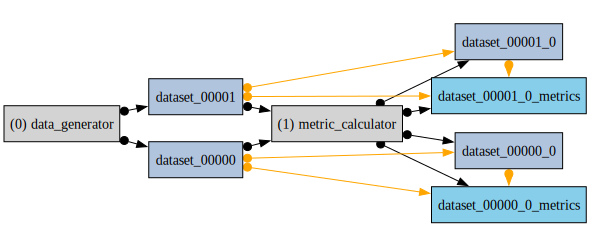

In [18]:
build_micro_graph(env_persist.delta_root)

## Validation

Chains enforce two constraints at `add()` time:

1. **No curators** — only creator operations can be chained. Curator
   operations (Filter, Merge) have different execution semantics and
   must be separate pipeline steps.
2. **Type compatibility** — when operations are added, the builder checks
   that the previous operation's output types are compatible with the
   next operation's input types.

In [19]:
from artisan.operations.curator.filter import Filter
from artisan.orchestration.chain_builder import ChainBuilder

builder = ChainBuilder(pipeline=None)
try:
    builder.add(Filter)
except TypeError as e:
    print(f"Caught TypeError: {e}")

Caught TypeError: Curator operations cannot be used in chains. 'filter' overrides execute_curator().


In [20]:
# Type mismatch: MetricCalculator outputs metrics, DataTransformer expects datasets
builder = ChainBuilder(pipeline=None)
builder.add(MetricCalculator)
try:
    builder.add(DataTransformer, role_mapping={"metrics": "dataset"})
except TypeError as e:
    print(f"Caught TypeError: {e}")

Caught TypeError: Type mismatch: output 'metrics' produces 'metric' but input 'dataset' expects 'data'.


Both errors are caught immediately at `add()` time, before any execution
starts. This fail-fast behavior prevents wasted compute on malformed
chains.

## Summary

This tutorial covered composable operations with `pipeline.chain()`:

- **Basic chain** — `pipeline.chain().add(Op1).add(Op2).run()` executes
  multiple operations as a single pipeline step with in-memory artifact
  passing.
- **Fluent syntax** — `chain()` and `add()` return the builder, so calls
  compose into a single expression. Omit `name` for auto-generated step names.
- **Downstream wiring** — chain outputs are referenced with
  `pipeline.output(chain_name, role)`, just like regular steps.
- **Intermediates** — `intermediates="persist"` keeps intermediate
  artifacts in Delta Lake for debugging. Default `"discard"` only
  commits final outputs.
- **Validation** — curators are rejected, and type mismatches between
  adjacent operations are caught at `add()` time.

**Key takeaway:** Use `chain()` when operations are always run together
and the intermediate artifacts are not needed by other steps. This
eliminates unnecessary Delta Lake round-trips without changing the
pipeline's logical structure.

## Next steps

- [Error Visibility](06-error-visibility.ipynb) — handling empty filters and inspecting skipped steps
- [Step Overrides](05-advanced-patterns.ipynb) — customizing execution per step